In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Daily.csv')

# Create a 'Date' column from 'YEAR' and 'DOY'
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + ' ' + df['DOY'].astype(str), format='%Y %j')

# Set 'Date' as the index
df = df.set_index('Date')

# Sort the DataFrame by the new 'Date' index
df = df.sort_index()

# Replace all occurrences of -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("DataFrame reloaded, 'Date' column created and set as index, sorted, and -999 replaced with NaN.")
print(df.head())

DataFrame reloaded, 'Date' column created and set as index, sorted, and -999 replaced with NaN.
            YEAR  DOY    T2M     TS   QV2M   RH2M  PRECTOTCORR      PS  WS2M  \
Date                                                                           
2015-01-01  2015    1  25.07  25.10  18.17  90.98         4.16  100.15  6.58   
2015-01-02  2015    2  24.47  25.51  14.68  77.26         0.48  100.58  2.05   
2015-01-03  2015    3  24.76  25.71  15.59  80.55         0.30  100.76  1.60   
2015-01-04  2015    4  25.15  25.97  15.25  77.17         0.13  100.71  0.89   
2015-01-05  2015    5  23.89  24.95  12.85  70.42         0.10  100.70  3.47   

            GWETTOP  GWETROOT  
Date                           
2015-01-01     0.58      0.43  
2015-01-02     0.55      0.43  
2015-01-03     0.53      0.42  
2015-01-04     0.52      0.42  
2015-01-05     0.51      0.42  


## Handle Missing Numerical Values

### Subtask:
Fill any remaining missing numerical values (NaN) in the DataFrame using the mean of their respective columns to ensure data completeness for subsequent calculations.


**Reasoning**:
To address the missing numerical values, I will iterate through all columns in the DataFrame, identify numerical columns with NaN values, and impute them with the mean of their respective columns. Finally, I will display the sum of null values for each column to verify the imputation.



In [ ]:
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        if df[column].isnull().any():
            df[column].fillna(df[column].mean(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
YEAR           0
DOY            0
T2M            0
TS             0
QV2M           0
RH2M           0
PRECTOTCORR    0
PS             0
WS2M           0
GWETTOP        0
GWETROOT       0
dtype: int64


/tmp/ipython-input-1978029917.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


**Reasoning**:
The previous code produced a FutureWarning regarding chained assignment when using `inplace=True`. To resolve this, I will modify the imputation step to directly reassign the filled column back to the DataFrame, which is the recommended practice for avoiding such warnings and ensuring the changes are applied correctly.



In [ ]:
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        if df[column].isnull().any():
            df[column] = df[column].fillna(df[column].mean())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
YEAR           0
DOY            0
T2M            0
TS             0
QV2M           0
RH2M           0
PRECTOTCORR    0
PS             0
WS2M           0
GWETTOP        0
GWETROOT       0
dtype: int64


## Generate Monthly Features

### Subtask:
Convert daily data into monthly samples using 30-day rolling windows. Calculate the monthly cumulative rainfall (from 'PRECTOTCORR'), monthly average temperature (from 'T2M'), monthly average relative humidity (from 'RH2M'), and monthly average root-zone soil moisture (from 'GWETROOT'). Drop any rows with NaN values resulting from the rolling window operations.


**Reasoning**:
I need to calculate monthly features using a 30-day rolling window as specified in the instructions. This involves applying rolling sum for rainfall and rolling mean for temperature, relative humidity, and root-zone soil moisture. After calculating the new features, I will drop any rows with NaN values resulting from the rolling window operations and display the head of the DataFrame to verify the changes.



In [ ]:
df['monthly_cumulative_rainfall'] = df['PRECTOTCORR'].rolling(window=30).sum()
df['monthly_average_temperature'] = df['T2M'].rolling(window=30).mean()
df['monthly_average_relative_humidity'] = df['RH2M'].rolling(window=30).mean()
df['monthly_average_root_zone_soil_moisture'] = df['GWETROOT'].rolling(window=30).mean()
df.dropna(inplace=True)
print("DataFrame with new monthly features and NaNs dropped:")
print(df.head())

DataFrame with new monthly features and NaNs dropped:
            YEAR  DOY    T2M     TS   QV2M   RH2M  PRECTOTCORR      PS  WS2M  \
Date                                                                           
2015-01-30  2015   30  23.81  24.97  13.46  74.04         0.00  100.96  2.30   
2015-01-31  2015   31  23.62  25.07  13.18  73.72         0.43  100.97  2.20   
2015-02-01  2015   32  22.88  24.39  10.25  60.87         0.75  101.01  3.10   
2015-02-02  2015   33  22.59  24.06  11.37  67.46         0.00  101.16  3.14   
2015-02-03  2015   34  23.11  24.07  10.73  62.24         0.00  101.31  3.13   

            GWETTOP  GWETROOT  monthly_cumulative_rainfall  \
Date                                                         
2015-01-30     0.44      0.35                         5.17   
2015-01-31     0.44      0.35                         1.44   
2015-02-01     0.45      0.35                         1.71   
2015-02-02     0.43      0.35                         1.41   
2015-02-03   

## Normalize Monthly Features

### Subtask:
Apply Min-Max scaling to all the generated monthly climate features. The fitted scaler will be saved for consistent normalization of future data.


**Reasoning**:
To normalize the generated monthly climate features, I will import `MinMaxScaler`, identify the relevant columns, then fit and transform these columns using the scaler, and finally display the updated DataFrame head to verify the changes.



In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify the monthly climate feature columns
monthly_features = [
    'monthly_cumulative_rainfall',
    'monthly_average_temperature',
    'monthly_average_relative_humidity',
    'monthly_average_root_zone_soil_moisture'
]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the monthly feature columns
df[monthly_features] = scaler.fit_transform(df[monthly_features])

print("DataFrame with normalized monthly features:")
print(df[monthly_features].head())

DataFrame with normalized monthly features:
            monthly_cumulative_rainfall  monthly_average_temperature  \
Date                                                                   
2015-01-30                     0.012220                     0.153494   
2015-01-31                     0.003404                     0.148644   
2015-02-01                     0.004042                     0.143325   
2015-02-02                     0.003333                     0.136067   
2015-02-03                     0.003025                     0.129244   

            monthly_average_relative_humidity  \
Date                                            
2015-01-30                           0.153940   
2015-01-31                           0.133512   
2015-02-01                           0.114115   
2015-02-02                           0.098622   
2015-02-03                           0.080952   

            monthly_average_root_zone_soil_moisture  
Date                                                 

## Compute Monthly Agricultural Indices

### Subtask:
Calculate three monthly agricultural indices based on the normalized monthly features: Irrigation Index, Crop Index, and Agricultural Condition Level Index (ACLI) using the provided formulas.


**Reasoning**:
To calculate the new monthly agricultural indices, I will apply the given formulas using the normalized monthly features and add them as new columns to the DataFrame.



In [ ]:
df['Irrigation Index'] = (df['monthly_average_root_zone_soil_moisture'] + df['monthly_cumulative_rainfall']) / 2
df['Crop Index'] = (df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 3
df['ACLI'] = (df['monthly_cumulative_rainfall'] + df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 4

print("DataFrame with new agricultural indices:")
print(df[['Irrigation Index', 'Crop Index', 'ACLI']].head())

DataFrame with new agricultural indices:
            Irrigation Index  Crop Index      ACLI
Date                                              
2015-01-30          0.095296    0.161935  0.124506
2015-01-31          0.088658    0.152023  0.114868
2015-02-01          0.086748    0.142298  0.107734
2015-02-02          0.084442    0.133414  0.100894
2015-02-03          0.082338    0.123949  0.093718


## Generate Monthly Yield Feasibility Labels

### Subtask:
Categorize the calculated ACLI values into 'High', 'Medium', and 'Low' yield feasibility labels based on the top 33%, middle 33%, and bottom 33% quantiles, respectively.


**Reasoning**:
To categorize the 'ACLI' values, I will calculate the 33rd and 66th percentiles of the 'ACLI' column. Then, I'll use these percentiles to define the 'Low', 'Medium', and 'High' categories and apply them to a new 'Yield Feasibility' column. Finally, I will display the distribution of these categories.



In [ ]:
lower_bound = df['ACLI'].quantile(0.33)
upper_bound = df['ACLI'].quantile(0.66)

def assign_yield_feasibility(acli):
    if acli <= lower_bound:
        return 'Low'
    elif acli >= upper_bound:
        return 'High'
    else:
        return 'Medium'

df['Yield Feasibility'] = df['ACLI'].apply(assign_yield_feasibility)

print("Yield Feasibility categories and their counts:")
print(df['Yield Feasibility'].value_counts())

Yield Feasibility categories and their counts:
Yield Feasibility
High      1356
Low       1316
Medium    1316
Name: count, dtype: int64


In [ ]:
monthly_features = [
    'monthly_cumulative_rainfall',
    'monthly_average_temperature',
    'monthly_average_relative_humidity',
    'monthly_average_root_zone_soil_moisture'
]

X = df[monthly_features]
y_regression = df[['Irrigation Index', 'Crop Index', 'ACLI']]
y_classification = df['Yield Feasibility']

# Determine the split point (80% for training, 20% for testing)
split_point = int(len(df) * 0.8)

# Split the data into training and testing sets
X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_regression_train = y_regression.iloc[:split_point]
y_regression_test = y_regression.iloc[split_point:]

y_classification_train = y_classification.iloc[:split_point]
y_classification_test = y_classification.iloc[split_point:]

print("Shapes of the datasets:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_regression_train: {y_regression_train.shape}")
print(f"y_regression_test: {y_regression_test.shape}")
print(f"y_classification_train: {y_classification_train.shape}")
print(f"y_classification_test: {y_classification_test.shape}")

Shapes of the datasets:
X_train: (3190, 4)
X_test: (798, 4)
y_regression_train: (3190, 3)
y_regression_test: (798, 3)
y_classification_train: (3190,)
y_classification_test: (798,)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
import joblib

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_regression_train)

joblib.dump(dt_model, "regression_model.pkl")

print("Decision Tree Regressor trained and saved.")


Decision Tree Regressor trained and saved.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import joblib

# Instantiate the Decision Tree Classifier
classification_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

# Train the model
classification_model.fit(X_train, y_classification_train)

# Save the trained model
joblib.dump(classification_model, "classification_model.pkl")

print("Decision Tree Classifier trained and saved successfully.")


Decision Tree Classifier trained and saved successfully.


In [ ]:
import joblib

# Load the regression model
regression_model = joblib.load('regression_model.pkl')
print("Regression model loaded successfully.")

# Load the classification model
classification_model = joblib.load('classification_model.pkl')
print("Classification model loaded successfully.")

# Confirm availability and structure of test datasets
print("\nShapes of test datasets for evaluation:")
print(f"X_test: {X_test.shape}")
print(f"y_regression_test: {y_regression_test.shape}")
print(f"y_classification_test: {y_classification_test.shape}")

Regression model loaded successfully.
Classification model loaded successfully.

Shapes of test datasets for evaluation:
X_test: (798, 4)
y_regression_test: (798, 3)
y_classification_test: (798,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict the agricultural indices using the regression model
y_regression_pred = regression_model.predict(X_test)

# Convert predictions to a DataFrame for easier handling and comparison
y_regression_pred_df = pd.DataFrame(y_regression_pred, columns=y_regression_test.columns, index=y_regression_test.index)

print("Regression Model Evaluation:")
for col in y_regression_test.columns:
    mae = mean_absolute_error(y_regression_test[col], y_regression_pred_df[col])
    rmse = np.sqrt(mean_squared_error(y_regression_test[col], y_regression_pred_df[col]))
    r2 = r2_score(y_regression_test[col], y_regression_pred_df[col])

    print(f"\n{col}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R^2: {r2:.4f}")

Regression Model Evaluation:

Irrigation Index:
  MAE: 0.0244
  RMSE: 0.0350
  R^2: 0.9824

Crop Index:
  MAE: 0.0290
  RMSE: 0.0483
  R^2: 0.9435

ACLI:
  MAE: 0.0250
  RMSE: 0.0414
  R^2: 0.9622


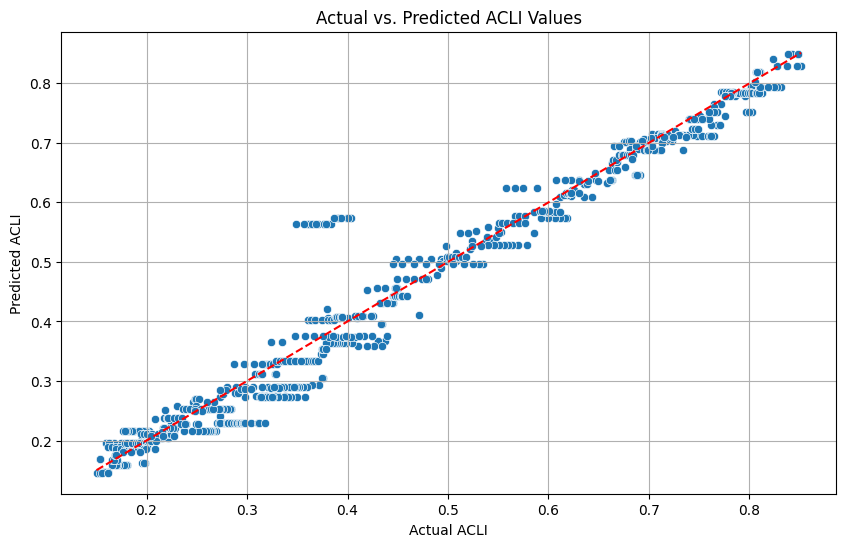

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_regression_test['ACLI'], y=y_regression_pred_df['ACLI'])
plt.xlabel('Actual ACLI')
plt.ylabel('Predicted ACLI')
plt.title('Actual vs. Predicted ACLI Values')
plt.plot([y_regression_test['ACLI'].min(), y_regression_test['ACLI'].max()],
         [y_regression_test['ACLI'].min(), y_regression_test['ACLI'].max()],
         'r--') # Add a diagonal line for perfect prediction
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict the 'Yield Feasibility' using the classification model
y_classification_pred = classification_model.predict(X_test)

print("Classification Model Evaluation:")

# Calculate and print Accuracy
accuracy = accuracy_score(y_classification_test, y_classification_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate and print Precision, Recall, F1-score for each class
# Use 'average=weighted' to account for class imbalance, if any, or None for per-class metrics
print("\nClassification Report:")
print(classification_report(y_classification_test, y_classification_pred))

Classification Model Evaluation:
Accuracy: 0.9048

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.94      0.97       269
         Low       0.90      0.88      0.89       269
      Medium       0.83      0.90      0.86       260

    accuracy                           0.90       798
   macro avg       0.91      0.90      0.91       798
weighted avg       0.91      0.90      0.91       798



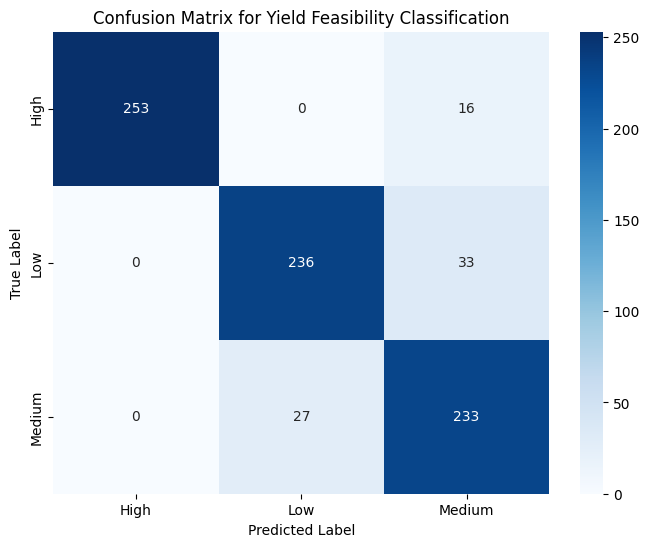

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
classes = sorted(y_classification_test.unique())
cm = confusion_matrix(y_classification_test, y_classification_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Yield Feasibility Classification')
plt.show()